In [47]:

import os
import cv2
import joblib
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms

from classification.models import CytologyClassifier
from segmentation.features import extract_features
from segmentation.models import UNet

def fuse_product(p_vgg, p_xgb, eps=1e-9):
    p = (p_vgg+eps) * (p_xgb+eps)
    return p / p.sum()

def fuse_sum(p_vgg, p_xgb, eps=1e-9):
    p = (p_vgg + eps) + (p_xgb + eps)
    return p / p.sum()
    
def fuse_weighted_avg(p_vgg, p_xgb, w=0.5):
    p = w * p_vgg + (1-w) * p_xgb
    return p / (p.sum() + 1e-12)

def softmax(z): 
    z = z - z.max()
    e = np.exp(z); return e / e.sum()

def fuse_logit_avg(p_vgg, p_xgb, w=0.5, eps=1e-9):
    z1 = np.log(p_vgg+eps); z2 = np.log(p_xgb+eps)  # logity ~ log-prob
    z  = w*z1 + (1-w)*z2
    return softmax(z)


def R1(p): return 1.0 - np.exp(-((p-1.0)**2)/2.0)
def R2(p): return 1.0 - np.tanh(((p-1.0)**2)/2.0)

def fuse_rank_based(p_vgg, p_xgb):
    r_vgg = R1(p_vgg) * R2(p_vgg)
    r_xgb = R1(p_xgb) * R2(p_xgb)
    r = r_vgg + r_xgb
    return -r

def entropy(p):
    return -(p * np.log(p + 1e-9)).sum()

def fuse_dynamic(p_vgg, p_xgb):
    e1, e2 = entropy(p_vgg), entropy(p_xgb)
    w1 = 1 / (e1 + 1e-9)
    w2 = 1 / (e2 + 1e-9)
    p = (w1 * p_vgg + w2 * p_xgb) / (w1 + w2)
    return p

def only_vgg(p_vgg, p_xgb):
    return p_vgg

def only_xgb(p_vgg, p_xgb):
    return p_xgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  

VGG_WEIGHTS = r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\32_0_0001_50_0608.pth'
ARCHITECTURE = 'vgg16'   # 'resnet18' or 'custom_cnn'

UNET_WEIGHTS = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\unet\unet_cell_nucleus_0208.pth"
LIGHTGBM_MODEL_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl"

# VGG
vgg_clf = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
vgg_clf.load(VGG_WEIGHTS)
vgg_clf.model.eval().to(device)

# U-Net
unet = UNet(in_channels=3, out_channels=2)  # 2 kanały: [komórka, jądro]
unet.load_state_dict(torch.load(UNET_WEIGHTS, map_location='cpu'))
unet.eval().to(device)

# LightGBM + enkoder + scaler
lightgbm_model = joblib.load(LIGHTGBM_MODEL_PATH)['model']
label_encoder = joblib.load(LIGHTGBM_MODEL_PATH)['label_encoder']


def preprocess_image_for_vgg(img_pil: Image.Image) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return tfm(img_pil)

def preprocess_image_for_unet(img_pil: Image.Image, size: int = 256) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),  # [0,1]
    ])
    return tfm(img_pil)

@torch.inference_mode()
def predict_vgg_probs(model_or_wrapper, image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    x = preprocess_image_for_vgg(img).unsqueeze(0).to(device)

    net = getattr(model_or_wrapper, "model", model_or_wrapper)
    net.eval()
    logits = net(x)                   

    probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    return probs


from segmentation.models import predict_masks 

def select_best_nucleus(mask: np.ndarray, image_shape=None) -> np.ndarray:
    # mask: (H,W) w [0,1] (jądro)
    m = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(m)

    if image_shape is None:
        h, w = m.shape
    else:
        h, w = image_shape
    center = np.array([w // 2, h // 2])

    best_score, best_contour = -np.inf, None
    for cnt in contours:
        if len(cnt) < 5:
            continue
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (MA, ma), angle = ellipse
        if MA == 0 or ma == 0:
            continue
        owalnosc = min(MA, ma) / max(MA, ma)
        nucleus_center = np.array([x, y])
        dist_to_center = np.linalg.norm(nucleus_center - center)
        score = owalnosc / (dist_to_center + 1e-5)
        if score > best_score:
            best_score, best_contour = score, cnt

    out = np.zeros_like(m, dtype=np.uint8)
    if best_contour is not None:
        cv2.drawContours(out, [best_contour], -1, 255, thickness=-1)
    return out  # (H,W) 0/255

FEATURE_NAMES = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']

def predict_gbm_probs(model, label_encoder, input_features: dict) -> np.ndarray:
    try:
        X_new = pd.DataFrame([[input_features[f] for f in FEATURE_NAMES]], columns=FEATURE_NAMES)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    proba = model.predict_proba(X_new)  # <-- tu nie używaj model["model"]
    classes_model = list(label_encoder.classes_)   
    probs_aligned = np.zeros(len(CLASS_NAMES), dtype=np.float32)
    for i, cname in enumerate(CLASS_NAMES):
        if cname in classes_model:
            probs_aligned[i] = proba[0, classes_model.index(cname)]
        else:
            probs_aligned[i] = 0.0

    s = probs_aligned.sum()
    if s > 0:
        probs_aligned = probs_aligned / s
    return probs_aligned


def run_pipeline(image_path: str, extract_features_fn, fuse_func) -> dict:
    # --- 1) VGG ---
    probs_vgg = predict_vgg_probs(vgg_clf, image_path)  # (K,)

    # --- 2) U-Net + cechy + XGBoost ---
    img_pil = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_image_for_unet(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    masks = predict_masks(unet, image_tensor, device=device)
    mask_cell = (masks[0] > 0.5).astype(np.uint8) * 255
    mask_nuc_soft = masks[1]
    best_nucleus = select_best_nucleus(mask_nuc_soft, image_shape=np.array(img_pil).shape[:2])


    feat_dict = extract_features_fn(best_nucleus, mask_cell)
    probs_gbm = predict_gbm_probs(lightgbm_model, label_encoder, feat_dict)  # (K,)


    fused = fuse_func(probs_vgg, probs_gbm)
    pred_idx = int(np.argmax(fused))
    pred_label = CLASS_NAMES[pred_idx]
    

    return {
        "vgg_probs": np.round(probs_vgg, 3),
        "gbm_probs": np.round(probs_gbm, 3),
        "fused_scores": np.round(fused, 3),
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "best_nucleus_mask": best_nucleus,
        "cell_mask": mask_cell,
        "features": feat_dict
    }


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

def metrics_and_plots(fuse_func):
    # --- zbieranie wyników ---
    y_true, y_pred, y_scores = [], [], []  # scores = wektory fused_probs

    test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
    valid_ext = (".bmp", ".jpg", ".jpeg", ".png")

    for class_name in os.listdir(test_root):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(valid_ext):
                continue

            image_path = os.path.join(class_dir, fname)
            result = run_pipeline(image_path, extract_features, fuse_func)

            y_true.append(class_name)                 # ground truth = nazwa folderu
            y_pred.append(result["pred_label"])       # predykcja
            y_scores.append(result["fused_scores"])   # wektor prob

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)   # shape = (N, K)

    CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']

    # --- metryki ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # --- confusion matrix (znormalizowana) ---
    cm_norm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Fusion, normalized) - {fuse_func.__name__}")
    plt.show()

    # --- ROC i AUC ---
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(CLASS_NAMES):
        y_true_bin = (y_true == cls).astype(int)  # one-vs-rest
        fpr, tpr, _ = roc_curve(y_true_bin, y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves for all classes - {fuse_func.__name__}")
    plt.legend(loc="lower right")
    plt.show()


Accuracy : 0.8835
Precision: 0.8872
Recall   : 0.8920
F1-score : 0.8789


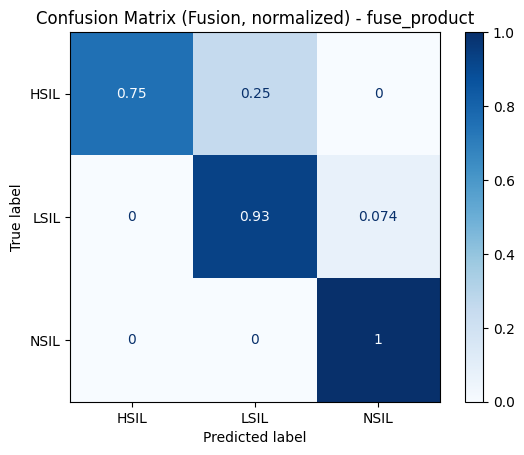

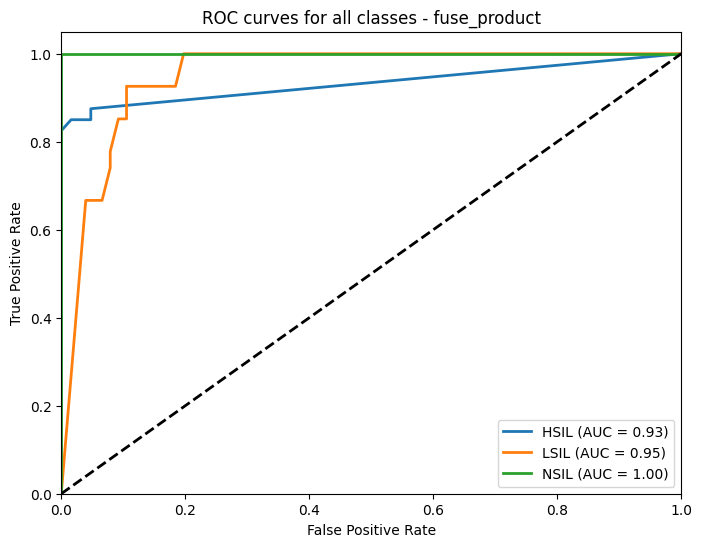

In [49]:
metrics_and_plots(fuse_product)

Accuracy : 0.8835
Precision: 0.8833
Recall   : 0.8880
F1-score : 0.8781


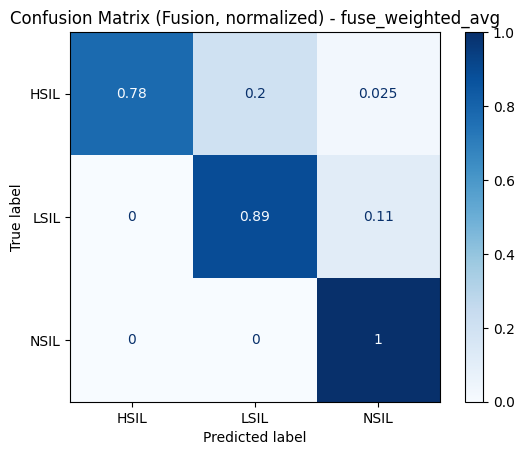

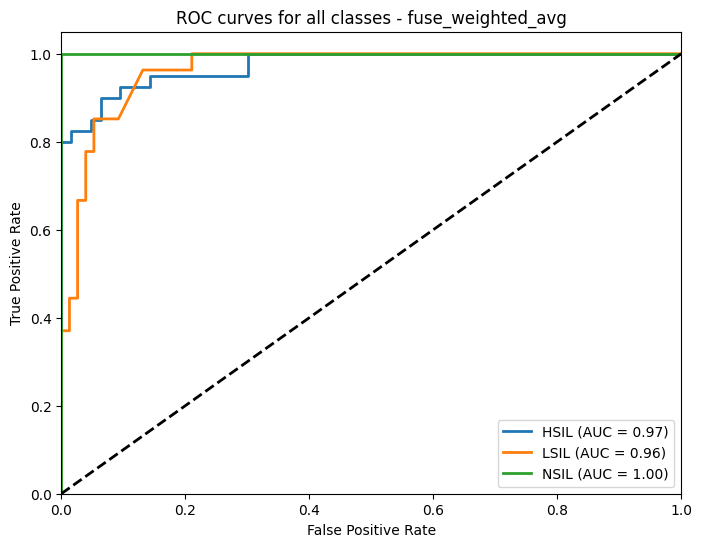

In [50]:
metrics_and_plots(fuse_weighted_avg)

Accuracy : 0.8835
Precision: 0.8872
Recall   : 0.8920
F1-score : 0.8789


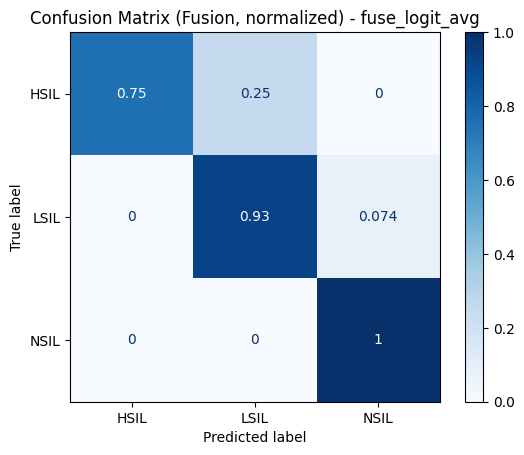

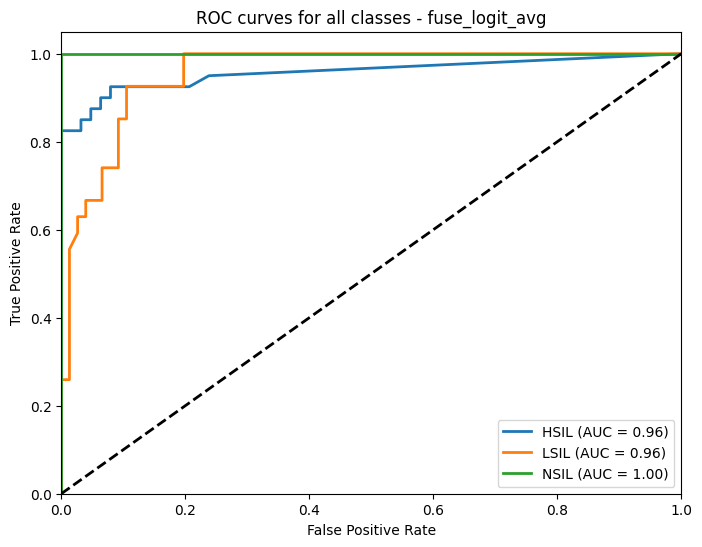

In [51]:
metrics_and_plots(fuse_logit_avg)

Accuracy : 0.8932
Precision: 0.8936
Recall   : 0.9003
F1-score : 0.8889


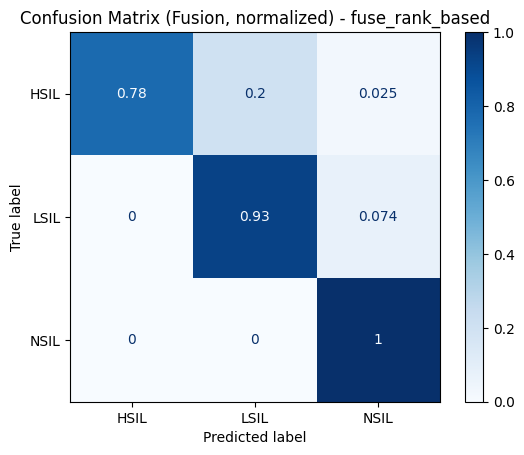

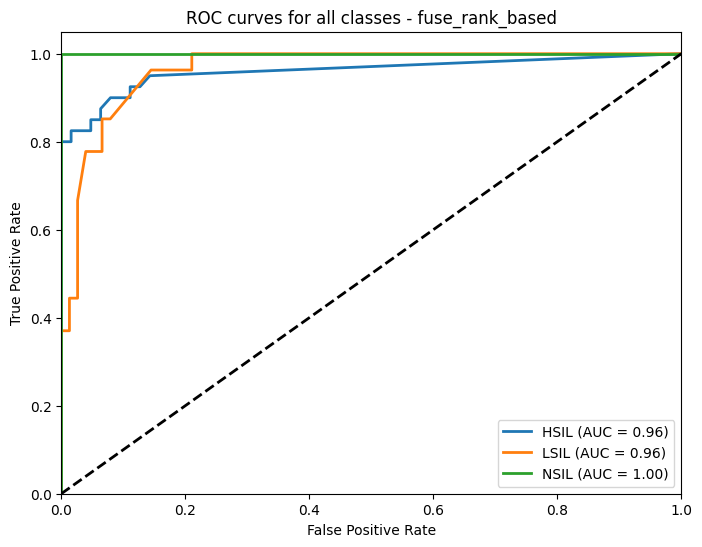

In [52]:
metrics_and_plots(fuse_rank_based)

In [75]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report
from segmentation.models import preprocess_image

y_true = []
y_pred = []

folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'

model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\unet\unet_cell_nucleus_0208.pth"))
model.to(device)



for subfolder in os.listdir(folder):
    true_class = os.path.basename(subfolder)
    for filename in os.listdir(os.path.join(folder, subfolder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(folder, subfolder, filename)
            predicted_class = run_pipeline(image_path, extract_features, fuse_rank_based)["pred_label"]
            y_true.append(true_class)
            y_pred.append(predicted_class)


acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
    )
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
    )

print("\n=== METRYKI (global) ===")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall    (macro):   {rec_macro:.4f}")
print(f"F1        (macro):   {f1_macro:.4f}")
print(f"Precision (weighted):{prec_weighted:.4f}")
print(f"Recall    (weighted):{rec_weighted:.4f}")
print(f"F1        (weighted):{f1_weighted:.4f}")

print("\n=== RAPORT (per klasa) ===")
print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in label_encoder.classes_],
        columns=[f"pred_{l}" for l in label_encoder.classes_],
    )
print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
print(cm_df)



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
tick_marks = np.arange(len(label_encoder.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
fig.tight_layout()
plt.close()


=== METRYKI (global) ===
Accuracy:            0.8000
Precision (macro):   0.7956
Recall    (macro):   0.8000
F1        (macro):   0.7964
Precision (weighted):0.7956
Recall    (weighted):0.8000
F1        (weighted):0.7964

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.7778    0.7000    0.7368        10
        LSIL     0.7000    0.7000    0.7000        10
        NSIL     0.9091    1.0000    0.9524        10

    accuracy                         0.8000        30
   macro avg     0.7956    0.8000    0.7964        30
weighted avg     0.7956    0.8000    0.7964        30


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL        0.7        0.3        0.0
true_LSIL        0.2        0.7        0.1
true_NSIL        0.0        0.0        1.0


Accuracy : 0.8835
Precision: 0.8833
Recall   : 0.8880
F1-score : 0.8781


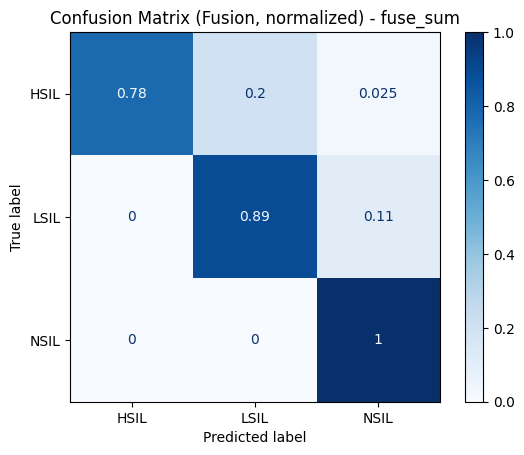

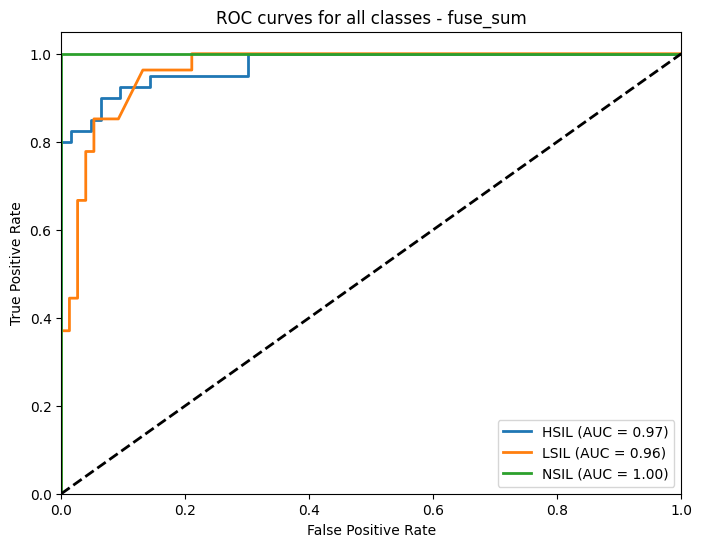

In [53]:
metrics_and_plots(fuse_sum)

Accuracy : 0.8835
Precision: 0.8833
Recall   : 0.8880
F1-score : 0.8781


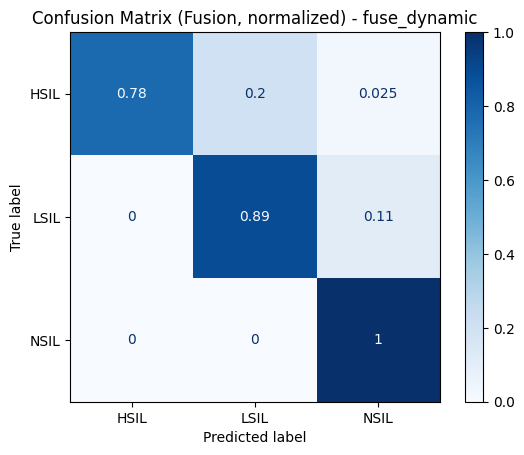

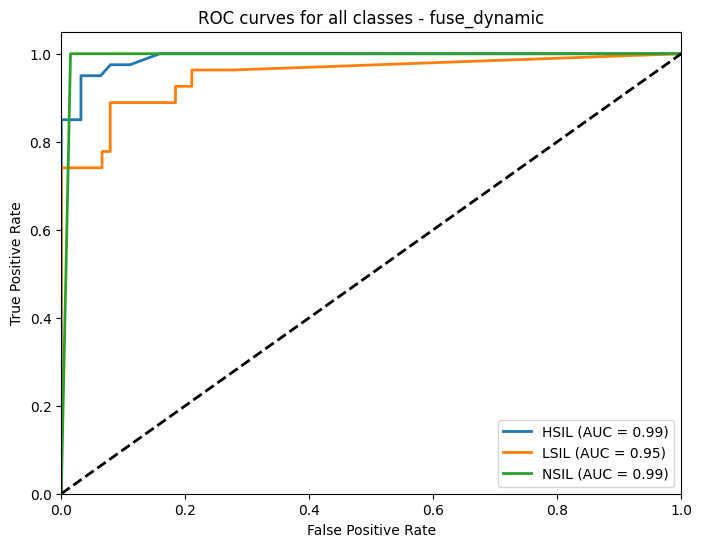

In [54]:
metrics_and_plots(fuse_dynamic)

In [55]:
def get_probs_vgg(folder_path):
    vgg_probs_hsil = []
    vgg_probs_lsil = []
    vgg_probs_nsil = []

    for subfolder in os.listdir(folder_path):
        for filename in os.listdir(os.path.join(folder_path, subfolder)):
            if not filename.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png')):
                continue
            image_path = os.path.join(folder_path, subfolder, filename)
            probs = predict_vgg_probs(vgg_clf, image_path)
            vgg_probs_hsil.append(probs[0])
            vgg_probs_lsil.append(probs[1])
            vgg_probs_nsil.append(probs[2])
    return vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil


In [56]:
vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\train")
df1 = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train"".csv")
df1['vgg_hsil'] = vgg_probs_hsil   
df1['vgg_lsil'] = vgg_probs_lsil
df1['vgg_nsil'] = vgg_probs_nsil

vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val")
df2 = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val"".csv")
df2['vgg_hsil'] = vgg_probs_hsil   
df2['vgg_lsil'] = vgg_probs_lsil
df2['vgg_nsil'] = vgg_probs_nsil
df_train = pd.concat([df1, df2], ignore_index=True)


In [57]:
vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test")
df_test = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test"".csv")
df_test['vgg_hsil'] = vgg_probs_hsil   
df_test['vgg_lsil'] = vgg_probs_lsil
df_test['vgg_nsil'] = vgg_probs_nsil
df_test.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,EqN,EqC,NCEq,OrN,OrC,NCOr,class,vgg_hsil,vgg_lsil,vgg_nsil
0,21667,42367,0.511412,752.867092,783.293499,0.961156,160.914810,0.719010,193.940713,0.806122,...,166.094194,232.257055,0.715131,0.259092,1.956773,0.132408,HSIL,1.000000,8.241411e-10,2.420213e-12
1,21843,39441,0.553815,679.068103,753.653889,0.901034,162.852386,0.756039,194.164878,0.833825,...,166.767417,224.093375,0.744187,-6.997945,-0.988006,7.082900,HSIL,1.000000,2.976666e-10,9.443071e-15
2,508,1218,0.417077,90.183765,138.710677,0.650157,17.000000,0.453616,35.693137,0.733489,...,25.432375,39.380271,0.645815,0.190405,0.275945,0.690009,HSIL,0.997926,1.269732e-03,8.047319e-04
3,334,1068,0.312734,71.941125,129.497474,0.555541,14.310834,0.447214,28.844410,0.587561,...,20.621882,36.875735,0.559226,-1.910850,-1.984336,0.962967,HSIL,0.937532,5.881651e-02,3.651587e-03
4,20047,41502,0.483037,615.813270,785.227484,0.784248,152.724228,0.691060,180.709712,0.699014,...,159.764305,229.873851,0.695009,-1.273165,1.315313,-0.967956,HSIL,0.999999,1.315980e-06,2.660284e-10


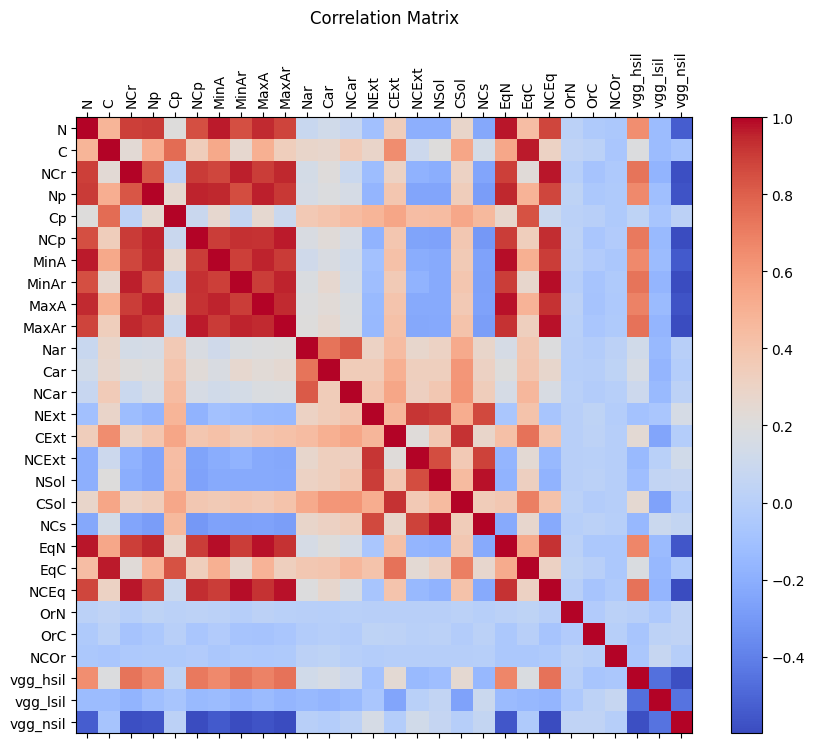

In [58]:
corr = df_train.drop(columns=['class']).corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

In [59]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

In [60]:
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2]
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
    }
}

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [62]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"segmentation/models/joined/best_model_{name}.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:36:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5540
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 28
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [63]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
2,RandomForest,Test,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.902913,0.909910,0.916667,0.900298
0,SVM,Test,"{'clf__C': 10, 'clf__gamma': 0.001, 'clf__kern...",0.902913,0.903869,0.912654,0.899940
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.893204,0.903509,0.908333,0.890450
4,LightGBM,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.893204,0.903509,0.908333,0.890450
1,NeuralNet,Test,"{'clf__activation': 'tanh', 'clf__alpha': 0.00...",0.893204,0.896655,0.904321,0.890156


In [64]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {cls_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


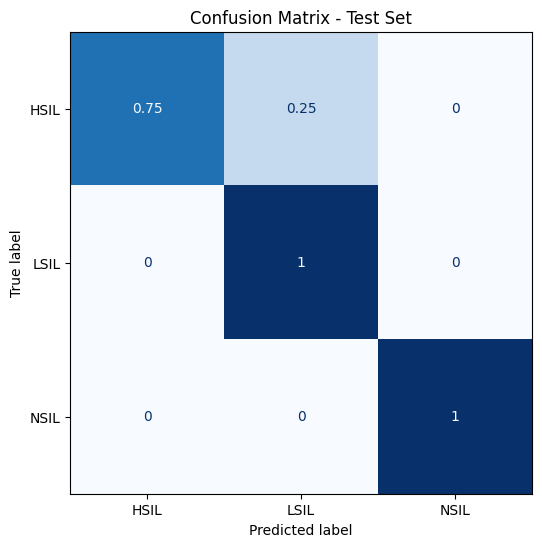

In [ ]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\joined\best_model_RandomForest.pkl")
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

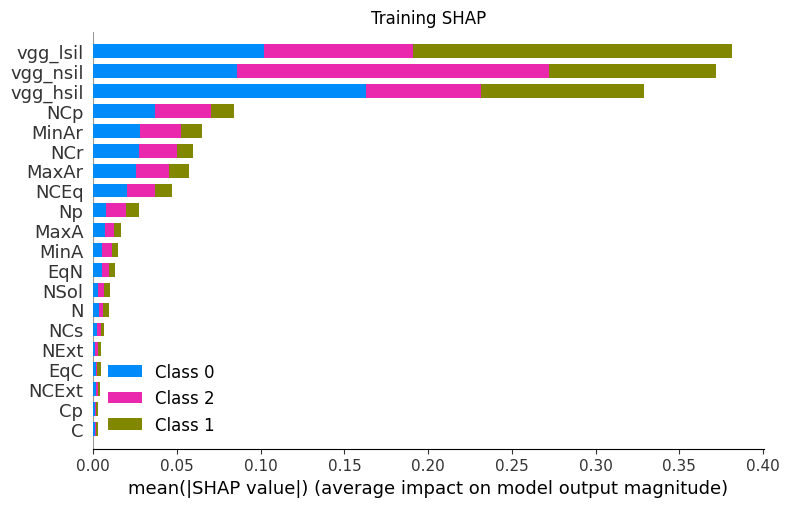

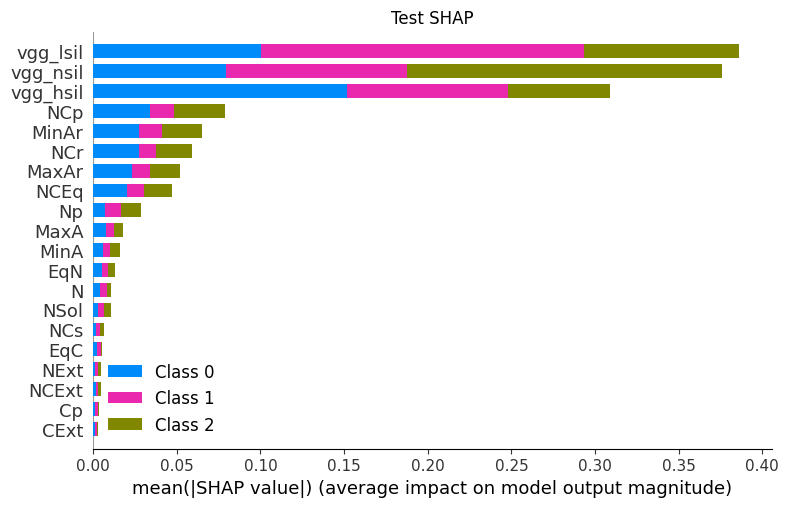

In [72]:
import shap

train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('Training SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

In [74]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report
from segmentation.models import preprocess_image

y_true = []
y_pred = []
label_encoder = model_class["label_encoder"]
pipe = model_class["model"]
folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'

model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\unet\unet_cell_nucleus_0208.pth"))
model.to(device)

def predict_fused(pipe, label_encoder, image_path):
    pil_image, input_tensor = preprocess_image(image_path)
    predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
    cell_mask = predicted_masks[0]
    nucleus_mask = predicted_masks[1]
    features = extract_features(nucleus_mask, cell_mask)

    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    X_new = pd.DataFrame([[features[feat] for feat in feature_names]], columns=feature_names)

    probs = predict_vgg_probs(vgg_clf, image_path)
    X_new["vgg_hsil"] = probs[0]
    X_new["vgg_lsil"] = probs[1]
    X_new["vgg_nsil"] = probs[2]

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class

for subfolder in os.listdir(folder):
    true_class = os.path.basename(subfolder)
    for filename in os.listdir(os.path.join(folder, subfolder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(folder, subfolder, filename)
            predicted_class = predict_fused(pipe, label_encoder, image_path)
            y_true.append(true_class)
            y_pred.append(predicted_class)


acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
    )
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
    )

print("\n=== METRYKI (global) ===")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall    (macro):   {rec_macro:.4f}")
print(f"F1        (macro):   {f1_macro:.4f}")
print(f"Precision (weighted):{prec_weighted:.4f}")
print(f"Recall    (weighted):{rec_weighted:.4f}")
print(f"F1        (weighted):{f1_weighted:.4f}")

print("\n=== RAPORT (per klasa) ===")
print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in label_encoder.classes_],
        columns=[f"pred_{l}" for l in label_encoder.classes_],
    )
print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
print(cm_df)



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
tick_marks = np.arange(len(label_encoder.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
fig.tight_layout()
plt.close()


=== METRYKI (global) ===
Accuracy:            0.8333
Precision (macro):   0.8558
Recall    (macro):   0.8333
F1        (macro):   0.8359
Precision (weighted):0.8558
Recall    (weighted):0.8333
F1        (weighted):0.8359

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8750    0.7000    0.7778        10
        LSIL     0.6923    0.9000    0.7826        10
        NSIL     1.0000    0.9000    0.9474        10

    accuracy                         0.8333        30
   macro avg     0.8558    0.8333    0.8359        30
weighted avg     0.8558    0.8333    0.8359        30


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL        0.7        0.3        0.0
true_LSIL        0.1        0.9        0.0
true_NSIL        0.0        0.1        0.9
